In [1]:
using Norma
using YAML
input_file = "cubes.yaml"
using Pkg
using Glob
using CSV
using DataFrames
using Plots

DDNN_ON = false


false

In [2]:
# Function to read and concatenate CSV files
function read_and_concatenate_csvs(file_pattern::String)
    # Use Glob to find all matching files
    files = glob(file_pattern, pwd())  # pwd() gives the current working directory
    data_frames = DataFrame[]
    for file in files
        df = CSV.File(file, header=false) |> DataFrame
        push!(data_frames, df)
    end
    return vcat(data_frames...)
end

function plot_ensemble()
    # Detect and read kinetic and time data
    kinetic_1 = read_and_concatenate_csvs("cube-1-kinetic-*.csv")
    kinetic_2 = read_and_concatenate_csvs("cube-2-kinetic-*.csv")
    internal_1 =  read_and_concatenate_csvs("cube-1-potential-*.csv")
    internal_2 =  read_and_concatenate_csvs("cube-2-potential-*.csv")
    time = read_and_concatenate_csvs("cube-1-time-*.csv")
    # Extract the values (assuming the values are in the first column)
    kinetic_1 = kinetic_1[!, 1]
    kinetic_2 = kinetic_2[!, 1]
    time = time[!, 1]
    internal_1 = internal_1[!, 1]
    internal_2 = internal_2[!, 1]

    total_energy_1 = kinetic_1 + internal_1 
    total_energy_2 = kinetic_2 + internal_2 

    # Create the plot
    p1 = plot(time, kinetic_1, label="Kinetic Energy", xlabel="Time", ylabel="Energy", title="Cube 1 Energies", legend=:topright)
    plot!(time, internal_1, label="Internal Energy")
    plot!(time, total_energy_1, label="System Energy")
    hline!([kinetic_1[1]], label="Analytical Cube 1 Energy", linestyle=:dash, color=:red)

    p2 = plot(time, kinetic_2, label="Kinetic Energy", xlabel="Time", ylabel="Energy", title="Cube 2 Energies", legend=:topright)
    plot!(time, internal_2, label="Internal Energy")
    plot!(time, total_energy_2, label="System Energy")
    hline!([kinetic_2[1]], label="Analytical Cube 2 Energy", linestyle=:dash, color=:red)

    p3 = plot(time, total_energy_1 + total_energy_2, label="Whole Simulation Energy", xlabel="Time", ylabel="Energy", title="Energy Distribution", legend=:topright)
    plot!(time, total_energy_1, label="Cube 1")
    plot!(time, total_energy_2, label="Cube 2")
    hline!([(total_energy_1 + total_energy_2)[1]], label="Analytical Whole Sim Energy", linestyle=:dash, color=:red)

    display(p1)
    display(p2)
    display(p3)
end


plot_ensemble (generic function with 1 method)

# Symmetric Case

In [3]:
if DDNN_ON
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-cubes/symmetric")
else
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-off-cubes/symmetric")
end
simulation_base = Norma.run(input_file)
println("Complete")

[NORMA]   BEGIN SIMULATION
[SETUP]   Reading from cubes.yaml
    [DOMAIN]  cube-1
    [DOMAIN]  cube-2
[ACCELER] Computing Initial Acceleration...
[ACCELER] Computing Initial Acceleration...
[STOP]    [0/42, 0%] : Time = -2.0000e-04
[OUTPUT]  Exodus II Database for cube-1 [EXO]
[OUTPUT]  Comma Separated Values for cube-1 [CSV]
[OUTPUT]  Exodus II Database for cube-2 [EXO]
[OUTPUT]  Comma Separated Values for cube-2 [CSV]
    [DOMAIN]  cube-1
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 1.326e-07 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 2.180e-07 : |r| = 1.644e+00 : [DONE]
    [DOMAIN]  cube-2
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 5.628e-08 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 2.258e-07 : |r| = 4.012e+00 : [DONE]
[STOP]    [1/42, 2%] : Time = -1.0000e-04
[OUTPUT]  Exodus II Database for cube-1 [EXO]
[OUTPUT]  Com

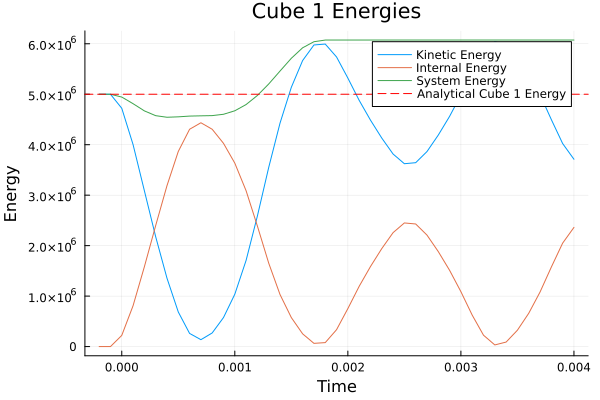

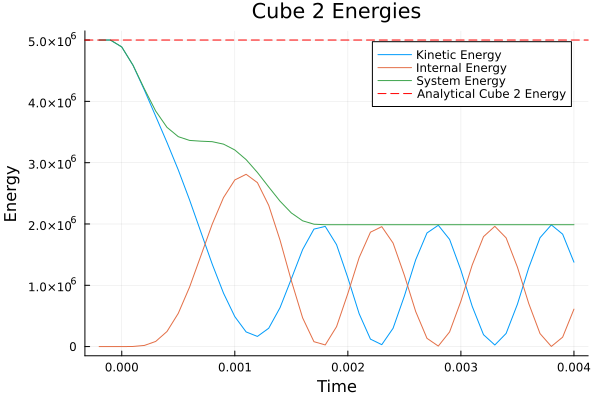

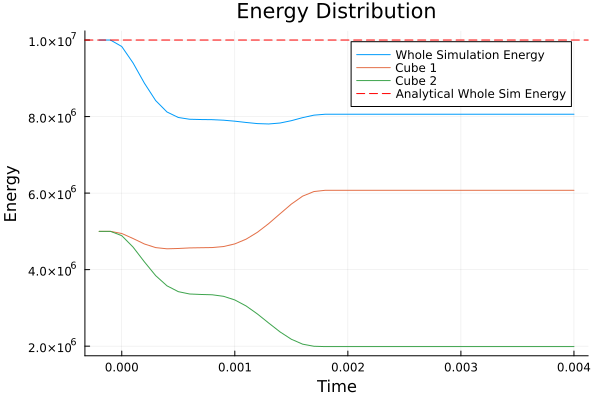

In [4]:
plot_ensemble()

# Anti-symm Mass

In [5]:
if DDNN_ON
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-cubes/mass")
else
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-off-cubes/mass")
end
simulation_mass = Norma.run(input_file)
println("Complete")

[NORMA]   BEGIN SIMULATION
[SETUP]   Reading from cubes.yaml
    [DOMAIN]  cube-1
    [DOMAIN]  cube-2
[ACCELER] Computing Initial Acceleration...
[ACCELER] Computing Initial Acceleration...
[STOP]    [0/42, 0%] : Time = -2.0000e-04
[OUTPUT]  Exodus II Database for cube-1 [EXO]
[OUTPUT]  Comma Separated Values for cube-1 [CSV]
[OUTPUT]  Exodus II Database for cube-2 [EXO]
[OUTPUT]  Comma Separated Values for cube-2 [CSV]
    [DOMAIN]  cube-1
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 1.326e-07 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 2.180e-07 : |r| = 1.644e+00 : [DONE]
    [DOMAIN]  cube-2
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 5.628e-08 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 2.267e-07 : |r| = 4.027e+00 : [DONE]
[STOP]    [1/42, 2%] : Time = -1.0000e-04
[OUTPUT]  Exodus II Database for cube-1 [EXO]
[OUTPUT]  Com

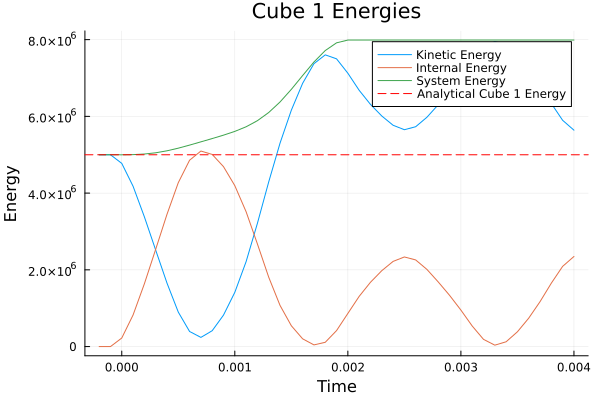

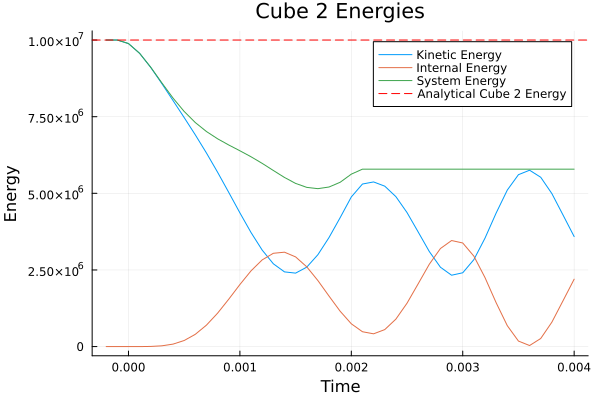

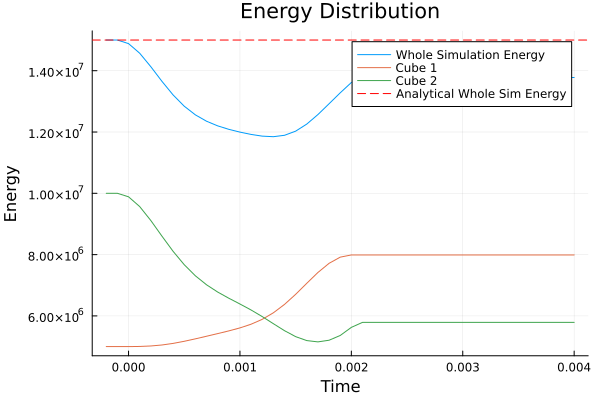

In [6]:
plot_ensemble()

# Anti-symm velocity

In [7]:
if DDNN_ON
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-cubes/velocity")
else
    cd("/Users/bphung/Work/software/Norma.jl/examples/contact/implicit-dynamic/DDNN-off-cubes/velocity")
end
simulation_velocity = Norma.run(input_file)
println("Complete")

[NORMA]   BEGIN SIMULATION
[SETUP]   Reading from cubes.yaml
    [DOMAIN]  cube-1
    [DOMAIN]  cube-2
[ACCELER] Computing Initial Acceleration...
[ACCELER] Computing Initial Acceleration...
[CONTACT] Detected
[STOP]    [0/42, 0%] : Time = -2.0000e-04
[OUTPUT]  Exodus II Database for cube-1 [EXO]
[OUTPUT]  Comma Separated Values for cube-1 [CSV]
[OUTPUT]  Exodus II Database for cube-2 [EXO]
[OUTPUT]  Comma Separated Values for cube-2 [CSV]
[SCHWARZ] Iteration [1]
    [DOMAIN]  cube-1
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 3.459e+08 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 4.362e-07 : |r| = 1.261e-15 : [DONE]
    [DOMAIN]  cube-2
    [ADVANCE] Time = [-2.0000e-04, -1.0000e-04] : Δt = 1.0000e-04
        [SOLVE]   Iteration [0] |R| = 2.812e+08 : |r| = 1.000e+00 : [WAIT]
        [SOLVE]   Iteration [1] |R| = 3.786e-06 : |r| = 1.347e-14 : [DONE]
[SCHWARZ] Criterion [1] |ΔU| = 1.004e+00 : |ΔU|/|U| = 3.30

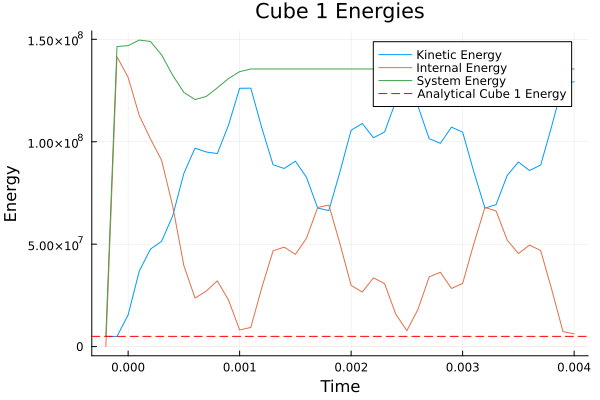

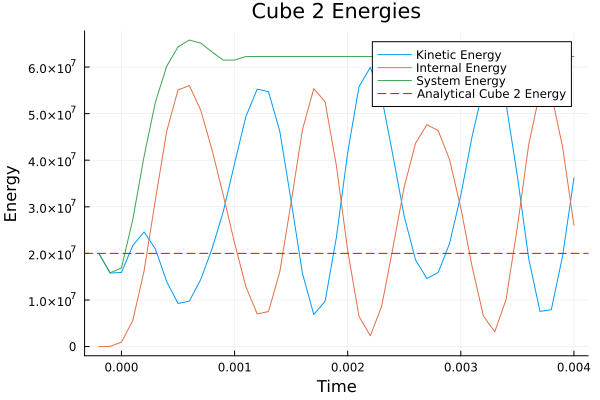

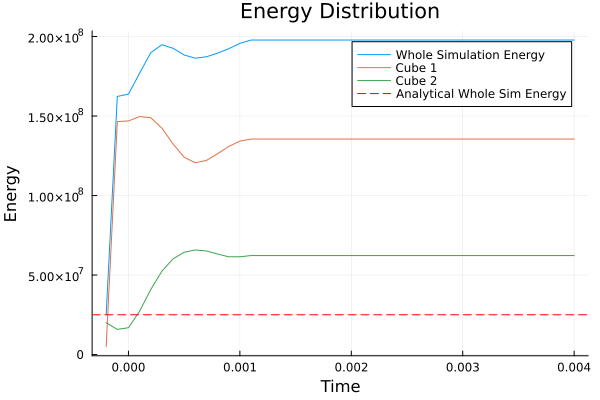

In [8]:
plot_ensemble()